Assignment: Exploratory Data Analysis (EDA)
Dataset: US COVID-19 Mobility & Cases (2021)
2240007430

In this assignment, I applied EDA techniques to analyze the relationship between COVID-19 cases and mobility trends (Retail, Workplaces, Residential) in the United States during 2021.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

# Data Loading and Cleaning



In [4]:
try:
    df = pd.read_csv('US_Covid_Mobility_2021.csv.csv')
    df['date'] = pd.to_datetime(df['date'])
except FileNotFoundError:
    df = pd.read_csv('US_Covid_Mobility_2021.csv')
    df['date'] = pd.to_datetime(df['date'])

df_clean = df.dropna(subset=['retail_recreation', 'workplaces', 'residential'])

print("Data Shape after cleaning:", df_clean.shape)
print("\nSummary Statistics:")
print(df_clean[['daily_cases', 'retail_recreation', 'workplaces']].describe())

Data Shape after cleaning: (524337, 17)

Summary Statistics:
         daily_cases  retail_recreation     workplaces
count  524337.000000      524337.000000  524337.000000
mean       59.285444           0.399039     -21.208953
std       316.459999          19.037933      13.679338
min         0.000000        -100.000000     -95.000000
25%         1.000000         -10.000000     -27.000000
50%        12.000000           0.000000     -19.000000
75%        44.000000          10.000000     -13.000000
max     99926.000000         409.000000     120.000000


# Data Visualization & Analysis
I created four visualizations to understand the trends:

National Daily Cases: To observe the infection waves throughout 2021.

Mobility Trends: To compare how time spent at "Workplaces" vs "Retail" changed.

Top 10 States: To see which states had the highest total cases.

Correlation Matrix: To measure the statistical relationship between staying home and infection rates.

# Graph 1: National Daily Cases

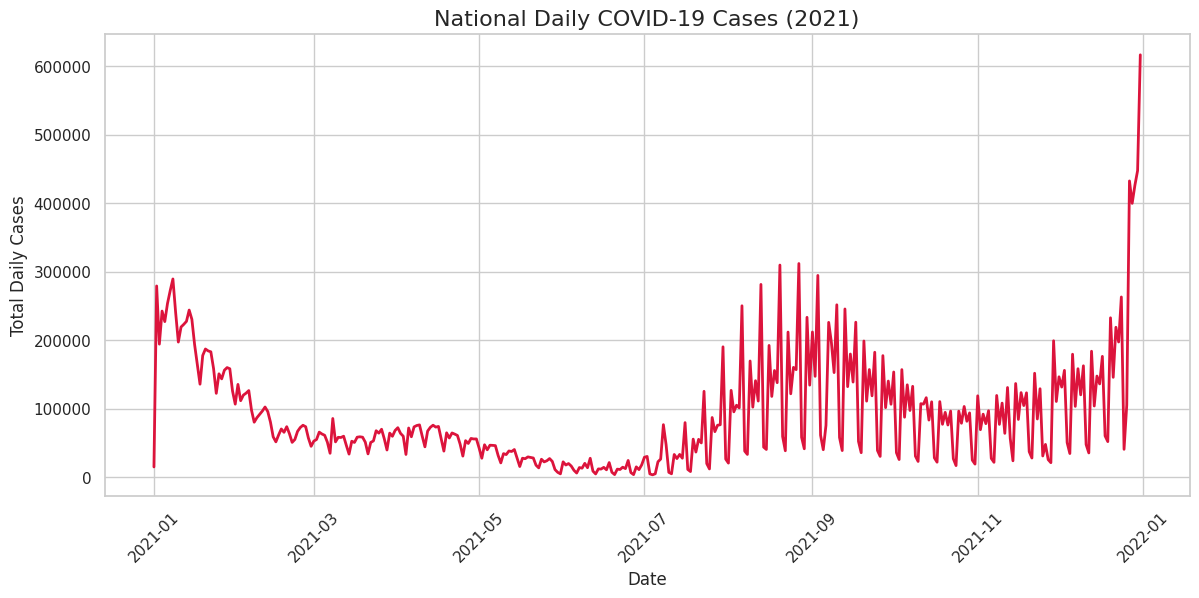

In [5]:
plt.figure(figsize=(14, 6))

daily_cases = df.groupby('date')['daily_cases'].sum().reset_index()


sns.lineplot(data=daily_cases, x='date', y='daily_cases', color='crimson', linewidth=2)

plt.title('National Daily COVID-19 Cases (2021)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Daily Cases', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Graph 2: Mobility Trends (Home vs. Work)

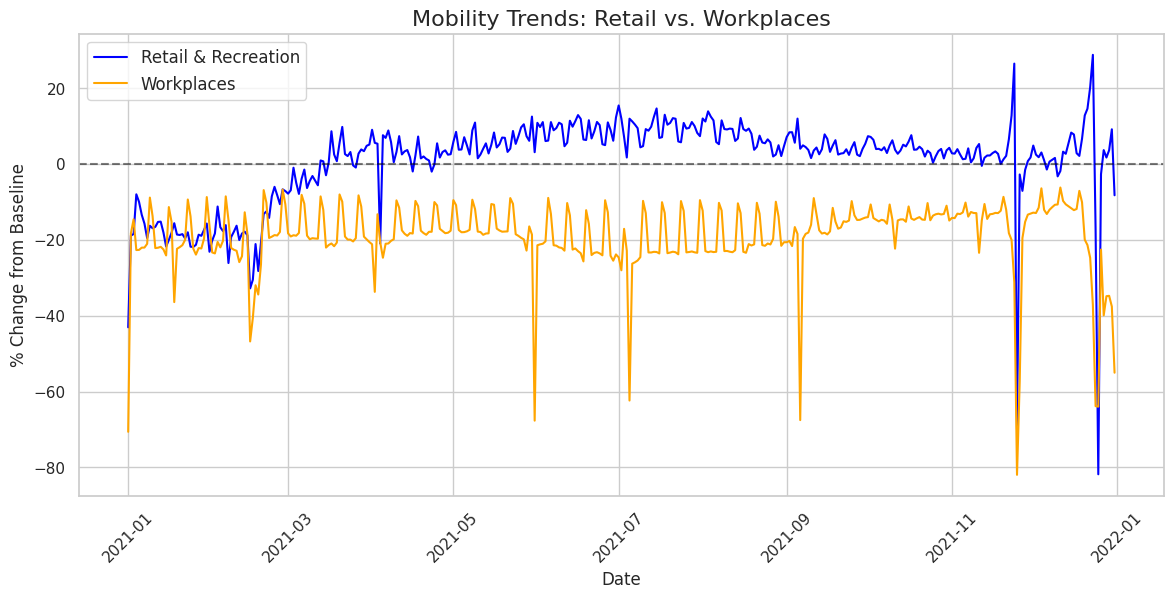

In [6]:
plt.figure(figsize=(14, 6))
mobility = df.groupby('date')[['retail_recreation', 'workplaces']].mean().reset_index()
sns.lineplot(data=mobility, x='date', y='retail_recreation', label='Retail & Recreation', color='blue')
sns.lineplot(data=mobility, x='date', y='workplaces', label='Workplaces', color='orange')
plt.title('Mobility Trends: Retail vs. Workplaces', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('% Change from Baseline', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)  # Add a baseline line at 0
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Graph 3: Top 10 States by Total Cases

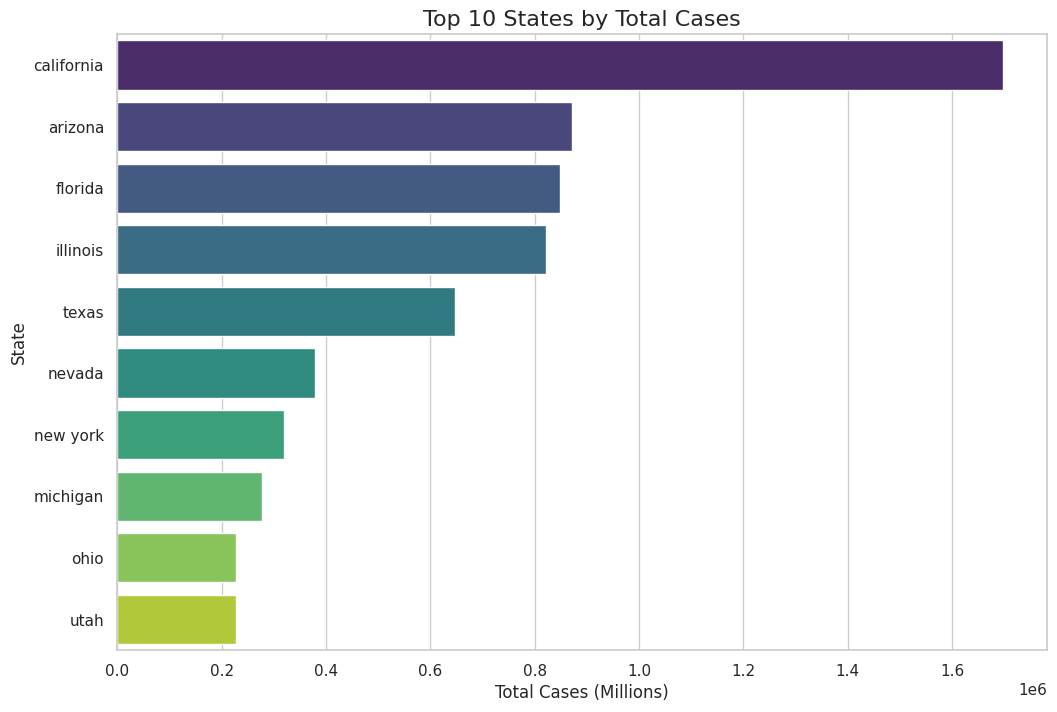

In [7]:
plt.figure(figsize=(12, 8))

top_states = df.groupby('state')['cases'].max().sort_values(ascending=False).head(10).reset_index()


sns.barplot(data=top_states, x='cases', y='state', palette='viridis', hue='state', legend=False)

plt.title('Top 10 States by Total Cases', fontsize=16)
plt.xlabel('Total Cases (Millions)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.show()

# Graph 4: Correlation Matrix

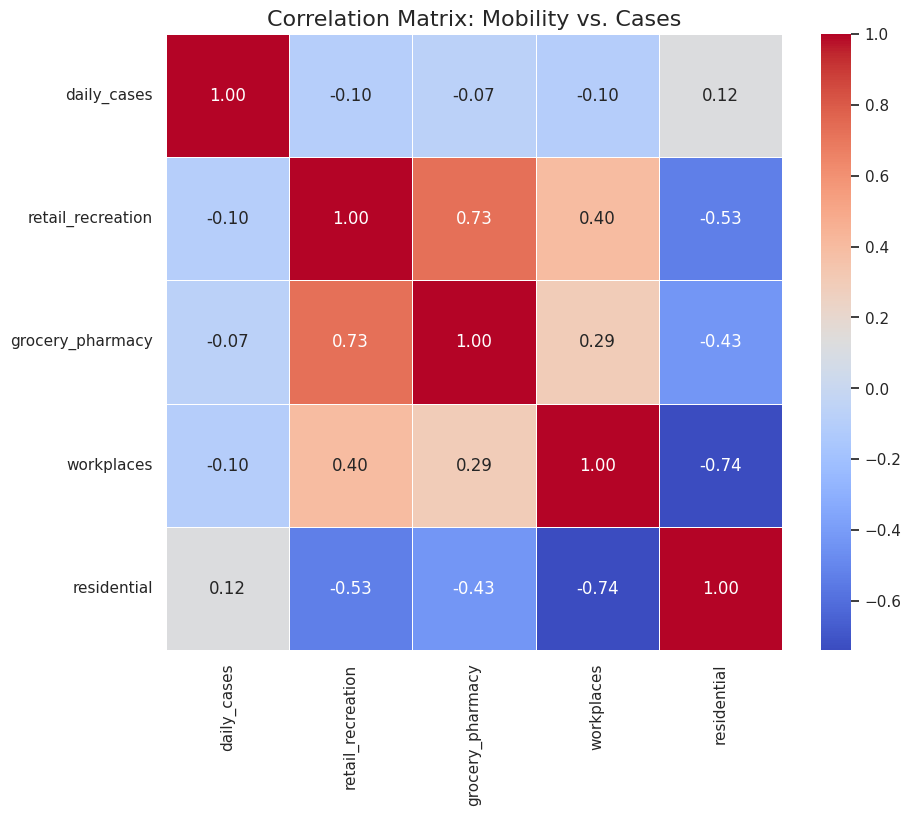

In [8]:
plt.figure(figsize=(10, 8))

corr_cols = ['daily_cases', 'retail_recreation', 'grocery_pharmacy', 'workplaces', 'residential']

corr_matrix = df_clean[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)

plt.title('Correlation Matrix: Mobility vs. Cases', fontsize=16)
plt.show()

#Data Quality Analysis
**Missing Values**: Significant gaps were found in mobility metrics, specifically in the retail_recreation, workplaces, and residential columns. These missing entries could distort our correlation analysis if not handled

**Presence of Outliers**: The daily_cases column shows an extreme range—varying from 0 to over 11,000 cases. With a mean of only 71, it's clear that a few extreme spikes (outliers) are present, likely from high-population centers or reporting anomalies

**Format Inconsistency**: The date column was imported as a string object, which prevents time-series plotting and grouping until it is converted to a proper datetime format

#Missing Value Strategy
**Strategy**: Listwise Deletion (Dropping rows with null values).
With over 20,000 records, removing rows with missing mobility data preserves the integrity of real-world observations

In [9]:
df_clean = df.dropna(subset=['retail_recreation', 'workplaces', 'residential'])
print(f"Cleaned dataset shape: {df_clean.shape}")

Cleaned dataset shape: (524337, 17)


#Outlier Handling (IQR Method)
To prevent extreme case spikes from skewing the results, we filter the daily_cases column using the Interquartile Range

In [10]:
Q1 = df_clean['daily_cases'].quantile(0.25)
Q3 = df_clean['daily_cases'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df_clean[(df_clean['daily_cases'] >= lower_bound) &
                        (df_clean['daily_cases'] <= upper_bound)]

print(f"Records after outlier removal: {df_filtered.shape[0]}")

Records after outlier removal: 464498


#Numerical Feature Normalization
Normalization is required to bring features like **cases** and **mobility percentages** onto the same scale for PCA

In [11]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

cols = ['daily_cases', 'retail_recreation', 'workplaces', 'residential']
data = df_filtered[cols]

scaler_mm = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_mm.fit_transform(data), columns=cols)

scaler_std = StandardScaler()
df_zscore = pd.DataFrame(scaler_std.fit_transform(data), columns=cols)

df_zscore.head()

,daily_cases,retail_recreation,workplaces,residential
0,-0.771015,-2.482328,-4.175067,5.255639
1,0.394917,-0.607592,0.026887,0.540293
2,0.716554,-0.711744,0.469198,0.315752
3,0.475326,0.121471,-0.415424,0.764833
4,3.209236,-0.190985,-0.046832,0.764833


#PCA and Explained Variance
Applying Principal Component Analysis to reduce dimensionality and identify the primary drivers of data variance.

PC1 Explained Variance: 53.41%
PC2 Explained Variance: 24.17%
PC3 Explained Variance: 16.06%
PC4 Explained Variance: 6.36%


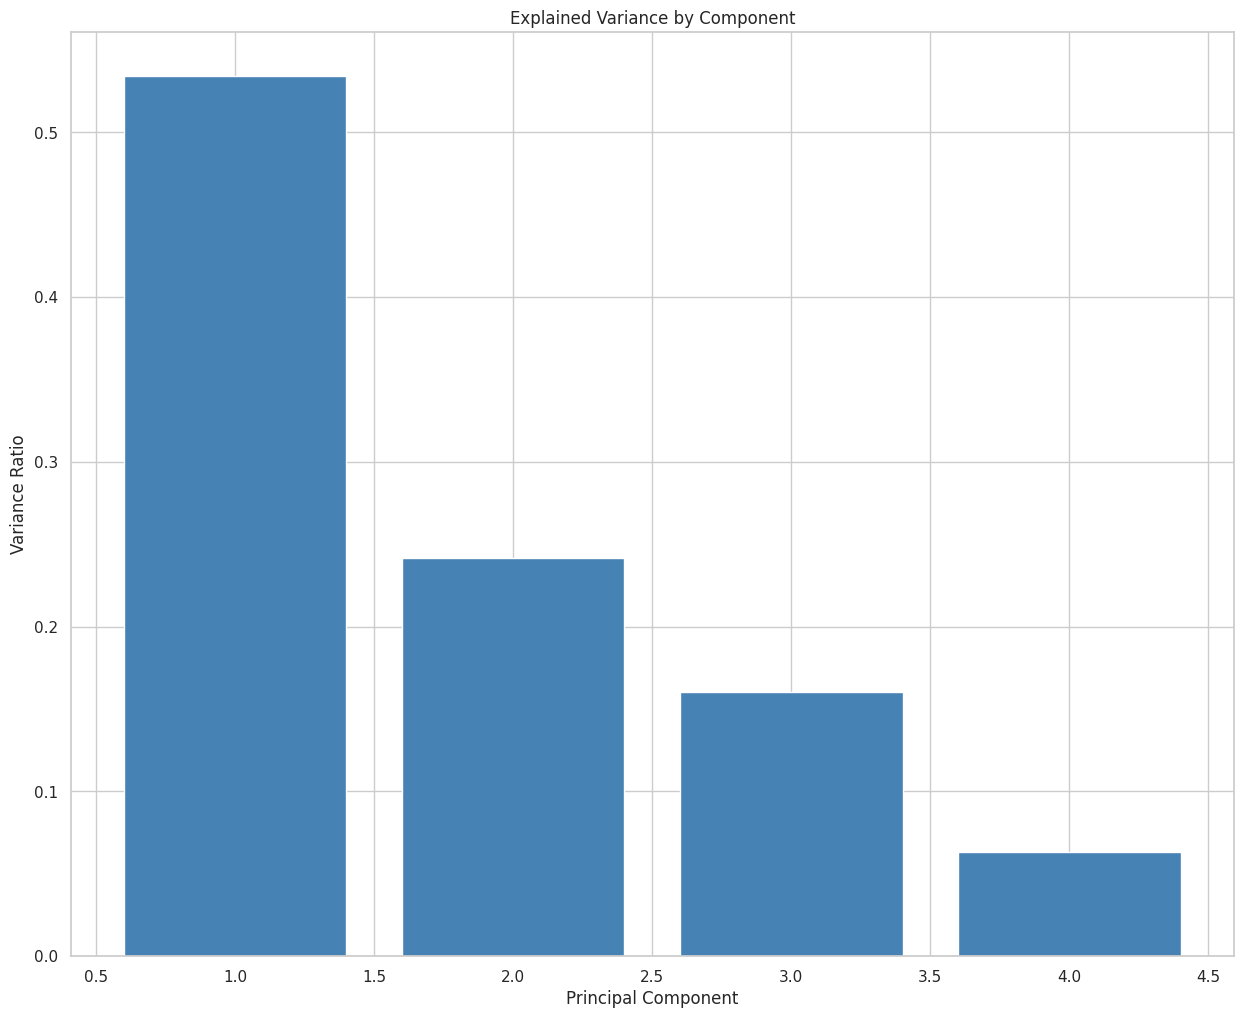

In [12]:
from sklearn.decomposition import PCA

pca = PCA()
pca_results = pca.fit_transform(df_zscore)

var_ratio = pca.explained_variance_ratio_
for i, v in enumerate(var_ratio):
    print(f"PC{i+1} Explained Variance: {v:.2%}")

plt.bar(range(1, 5), var_ratio, color='steelblue')
plt.title('Explained Variance by Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.show()